In [1]:
#necessary tools for training the model
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from torch .utils.data import DataLoader, Dataset
from torchsummary import summary
from torch.optim import Adam


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

print(os.listdir('/kaggle/input/datasets/ayuraj/asl-dataset/asl_dataset/'))

cuda
['n', '7', 'r', '2', 'b', 'i', 'f', 'h', '5', 'e', 'u', 'm', '8', 'x', '0', 'asl_dataset', 'k', 'q', 'y', 's', 'g', 'a', 'o', 't', 'v', 'z', '3', '1', 'c', '4', 'p', '9', 'l', '6', 'w', 'd', 'j']


In [2]:
image_paths = []
labels = []

for label in os.listdir('/kaggle/input/datasets/ayuraj/asl-dataset/asl_dataset/'):
    for image in os.listdir(f'/kaggle/input/datasets/ayuraj/asl-dataset/asl_dataset/{label}'):
        image_paths.append(f'/kaggle/input/datasets/ayuraj/asl-dataset/asl_dataset/{label}/{image}')
        labels.append(label)

data_df = pd.DataFrame(zip(image_paths, labels), columns=['image_paths', 'labels'])
data_df = data_df[data_df['labels']!='asl_dataset']

In [3]:
train = data_df.sample(frac=0.7)
test = data_df.drop(train.index)

val = test.sample(frac=0.5)
test = test.drop(val.index)

In [4]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df['labels'])

base_transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ]
)

In [5]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels']))

    def __len__(self):
        
        return self.dataframe.shape[0]


    def __getitem__(self, idx):
        image_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label
        

In [6]:
train_dataset = CustomImageDataset(test, transform=base_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [7]:
#calcualte mean and standard deviation for calcuating z-score normalization

channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
total_pixels = 0

for images, labels in train_loader:

    channel_sum += images.sum(dim=[0, 2, 3])
    channel_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    total_pixels += images.size(0) * images.size(2) * images.size(3)

mean = channel_sum / total_pixels
std = torch.sqrt(
    (channel_squared_sum / total_pixels) - (mean **2)
)

#TODO: MAKE SURE TO CONVERT TO CUDA WHEN TRAINING!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

print(f"Mean: {mean}")
print(f'Std: {std}')

Mean: tensor([0.2226, 0.1538, 0.1387])
Std: tensor([0.2997, 0.2197, 0.2084])


In [8]:
transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=mean.tolist(),
            std=std.tolist()
        )
    ]
)

train_dataset = CustomImageDataset(train, transform=transform)
val_dataset = CustomImageDataset(val, transform=transform)
test_dataset = CustomImageDataset(test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

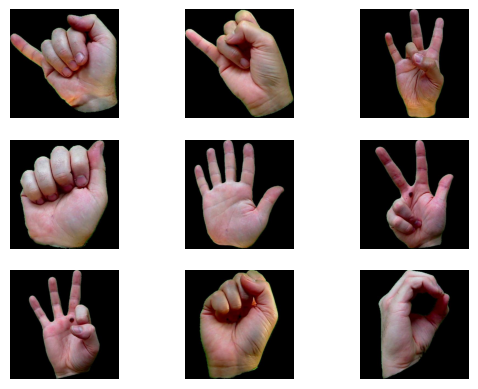

In [9]:
#visualize image

f, axs = plt.subplots(nrows=3, ncols=3)

for row in range(3):
    for col in range(3):
        image = Image.open(data_df.sample(n=1)['image_paths'].iloc[0]).convert('RGB')
        axs[row, col].imshow(image)
        axs[row, col].axis('off')
plt.show()

In [10]:
class Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size = 3, padding = 1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size = 3, padding = 1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size = 3, padding = 1)

        self.pooling = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear = nn.Linear((128*16*16), 128)
        self.output = nn.Linear(128, len(data_df['labels'].unique()))

    def forward(self, x):
        x = self.conv1(x)
        x = self.pooling(x)
        x = self.relu(x)
        
        x = self.conv2(x)
        x = self.pooling(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.pooling(x)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)

        return x
        

In [11]:
model = Net().to(device)

In [12]:
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                   [-1, 36]           4,644
Total params: 4,292,324
Trainable params: 4,292,324
Non-trainable params: 0
---------------------------

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

In [14]:
total_loss_train_plot = []
total_loss_val_plot = []

total_acc_train_plot = []
total_acc_val_plot = []

EPOCHS = 10

for epoch in range(EPOCHS):

    total_loss_train = 0
    total_loss_val = 0

    total_acc_train = 0
    total_acc_val = 0

    # =========================
    # Training
    # =========================

    model.train()

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        predict = model(inputs)

        train_loss = criterion(predict, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(predict, dim=1) == labels).sum().item()
        total_acc_train += train_acc

        optimizer.step()

    # =========================
    # Validation
    # =========================

    model.eval()

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            predict = model(inputs)

            val_loss = criterion(predict, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(predict, dim=1) == labels).sum().item()
            total_acc_val += val_acc

    # =========================
    # Metrics
    # =========================

    train_loss_avg = total_loss_train / len(train_loader)
    val_loss_avg = total_loss_val / len(val_loader)

    train_acc = total_acc_train / len(train_dataset) * 100
    val_acc = total_acc_val / len(val_dataset) * 100

    total_loss_train_plot.append(train_loss_avg)
    total_loss_val_plot.append(val_loss_avg)

    total_acc_train_plot.append(train_acc)
    total_acc_val_plot.append(val_acc)

    print(
        f"""Epoch {epoch + 1} / {EPOCHS}
Train Loss: {train_loss_avg:.4f}
Train Accuracy: {train_acc:.2f}%
Validation Loss: {val_loss_avg:.4f}
Validation Accuracy: {val_acc:.2f}%"""
    )

    print("=" * 100)

Epoch 1 / 10
Train Loss: 3.0255
Train Accuracy: 28.30%
Validation Loss: 1.8351
Validation Accuracy: 61.64%
Epoch 2 / 10
Train Loss: 0.9872
Train Accuracy: 73.47%
Validation Loss: 0.6267
Validation Accuracy: 81.75%
Epoch 3 / 10
Train Loss: 0.4644
Train Accuracy: 84.89%
Validation Loss: 0.4033
Validation Accuracy: 85.98%
Epoch 4 / 10
Train Loss: 0.3196
Train Accuracy: 90.34%
Validation Loss: 0.4228
Validation Accuracy: 85.71%
Epoch 5 / 10
Train Loss: 0.2518
Train Accuracy: 92.27%
Validation Loss: 0.2441
Validation Accuracy: 93.12%
Epoch 6 / 10
Train Loss: 0.1549
Train Accuracy: 95.62%
Validation Loss: 0.1968
Validation Accuracy: 94.18%
Epoch 7 / 10
Train Loss: 0.0918
Train Accuracy: 97.61%
Validation Loss: 0.1695
Validation Accuracy: 94.71%
Epoch 8 / 10
Train Loss: 0.0769
Train Accuracy: 97.44%
Validation Loss: 0.2250
Validation Accuracy: 91.80%
Epoch 9 / 10
Train Loss: 0.0766
Train Accuracy: 97.61%
Validation Loss: 0.1995
Validation Accuracy: 93.39%
Epoch 10 / 10
Train Loss: 0.0770
Trai

In [15]:
model.eval()

with torch.no_grad():

    total_loss_test = 0
    total_acc_test = 0

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        prediction = model(inputs)

        acc = (torch.argmax(prediction, dim=1) == labels).sum().item()
        total_acc_test += acc

        test_loss = criterion(prediction, labels)
        total_loss_test += test_loss.item()


test_loss_avg = total_loss_test / len(test_loader)
test_acc = total_acc_test / len(test_dataset) * 100

print(f'Test Loss: {test_loss_avg:.4f}')
print(f'Test Accuracy: {test_acc:.2f}%')

Test Loss: 0.3730
Test Accuracy: 90.98%


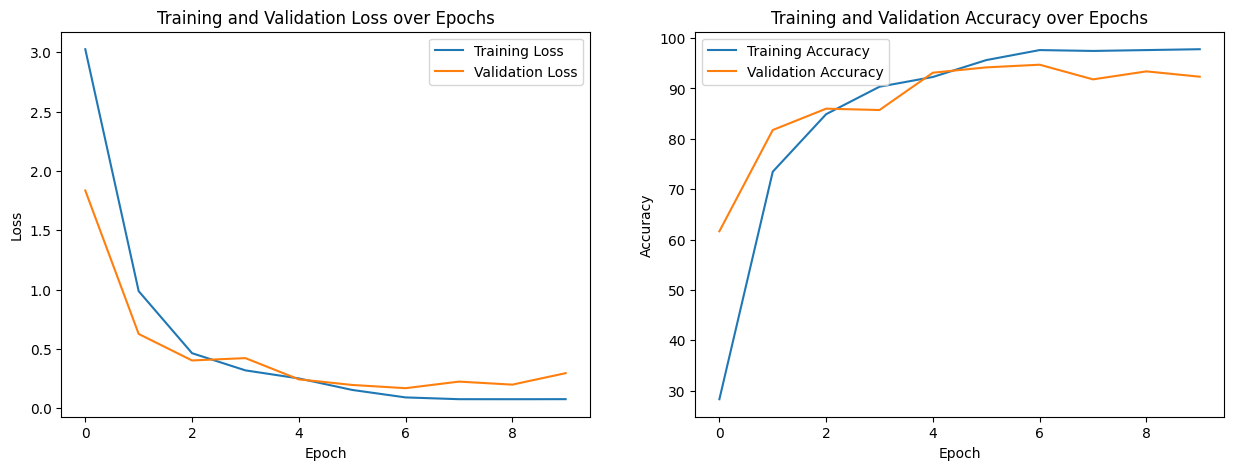

In [16]:
import matplotlib.pyplot as plt

# 1. Create subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# 2. Left Subplot: Loss
axs[0].plot(total_loss_train_plot, label='Training Loss')  # Fixed .plt to .plot
axs[0].plot(total_loss_val_plot, label='Validation Loss')  # Fixed .plt to .plot
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

# 3. Right Subplot: Accuracy
axs[1].plot(total_acc_train_plot, label='Training Accuracy')  # Fixed .plt to .plot
axs[1].plot(total_acc_val_plot, label='Validation Accuracy')  # Fixed .plt to .plot and fixed typo
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')  # Fixed 'Loss' to 'Accuracy'
axs[1].legend()

# 4. Display the figure
plt.show()  # Fixed plot.show() to plt.show()


In [17]:
torch.save(model.state_dict(), "asl_cnn.pth")